Generate Images
generate for ai_002_002, 0085
Start : 1746533259.083034
???
Time to get depth and calculate normal map and wd : 0.18208575248718262
Time for DeepLSD : 0.40645933151245117
Time to calculate sobels : 0.0814216136932373
Time for structural vs textural : 0.07513189315795898
Time for line splitting : 0.18372058868408203
Time to get CC : 0.001766204833984375
Number of connected components (including background): 152
Time to run Ransac : 0.4882183074951172
Number of connected components (including background): 152
Merged plane groups (via RAG): [{np.int32(1)}, {np.int32(2)}, {np.int32(11), np.int32(3), np.int32(20), np.int32(14)}, {np.int32(4)}, {np.int32(5)}, {np.int32(6)}, {np.int32(8)}, {np.int32(9)}, {np.int32(19), np.int32(12)}, {np.int32(13), np.int32(48), np.int32(17), np.int32(50), np.int32(51)}, {np.int32(38), np.int32(30), np.int32(15)}, {np.int32(16)}, {np.int32(23)}, {np.int32(65), np.int32(36), np.int32(113), np.int32(83), np.int32(118), np.int32(88), np.int32(122

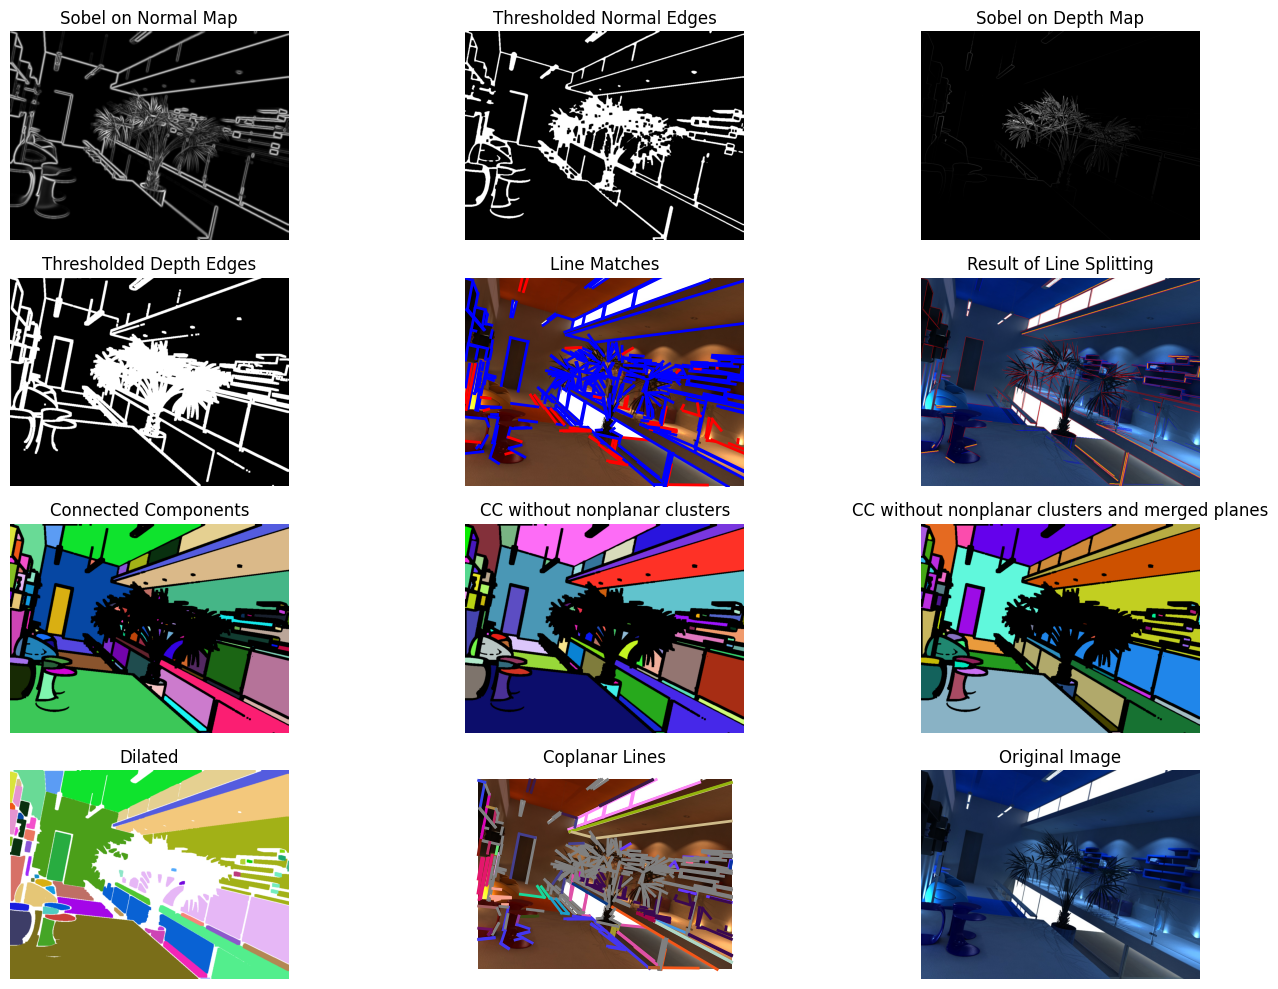

generate for ai_002_002, 0085
Start : 1746533262.762006
???
Time to get depth and calculate normal map and wd : 0.168992280960083
Time for DeepLSD : 0.27968692779541016
Time to calculate sobels : 0.06774473190307617
Time for structural vs textural : 0.06634306907653809
Time for line splitting : 0.16465377807617188
Time to get CC : 0.0010993480682373047
Number of connected components (including background): 152
Time to run Ransac : 0.4875321388244629
Number of connected components (including background): 152
Merged plane groups (via RAG): [{np.int32(1)}, {np.int32(2)}, {np.int32(11), np.int32(3), np.int32(20), np.int32(14)}, {np.int32(4)}, {np.int32(5)}, {np.int32(6)}, {np.int32(8)}, {np.int32(9)}, {np.int32(19), np.int32(12)}, {np.int32(13), np.int32(48), np.int32(17), np.int32(50), np.int32(51)}, {np.int32(38), np.int32(30), np.int32(15)}, {np.int32(16)}, {np.int32(23)}, {np.int32(65), np.int32(36), np.int32(113), np.int32(83), np.int32(118), np.int32(88), np.int32(122), np.int32(27),

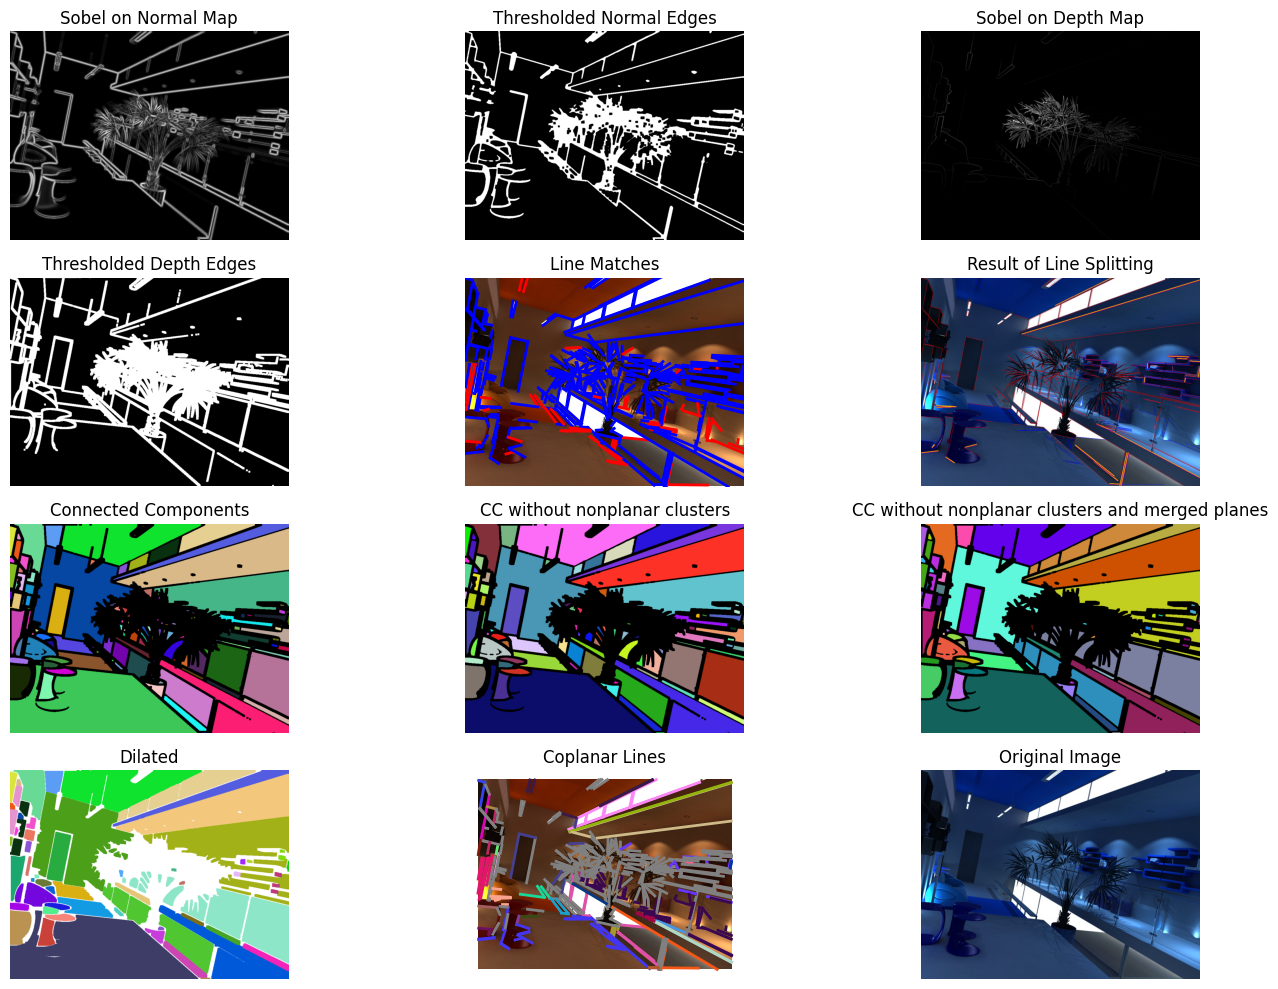

generate for ai_002_002, 0085
Start : 1746533266.2564418
???
Time to get depth and calculate normal map and wd : 0.13753867149353027
Time for DeepLSD : 0.43303608894348145
Time to calculate sobels : 0.0648648738861084
Time for structural vs textural : 0.06932640075683594
Time for line splitting : 0.17575311660766602
Time to get CC : 0.0010800361633300781
Number of connected components (including background): 152
Time to run Ransac : 0.488666296005249
Number of connected components (including background): 152
Merged plane groups (via RAG): [{np.int32(1)}, {np.int32(2)}, {np.int32(11), np.int32(3), np.int32(20), np.int32(14)}, {np.int32(4)}, {np.int32(5)}, {np.int32(6)}, {np.int32(8)}, {np.int32(9)}, {np.int32(19), np.int32(12)}, {np.int32(13), np.int32(48), np.int32(17), np.int32(50), np.int32(51)}, {np.int32(38), np.int32(30), np.int32(15)}, {np.int32(16)}, {np.int32(23)}, {np.int32(65), np.int32(36), np.int32(113), np.int32(83), np.int32(118), np.int32(88), np.int32(122), np.int32(27)

KeyboardInterrupt: 

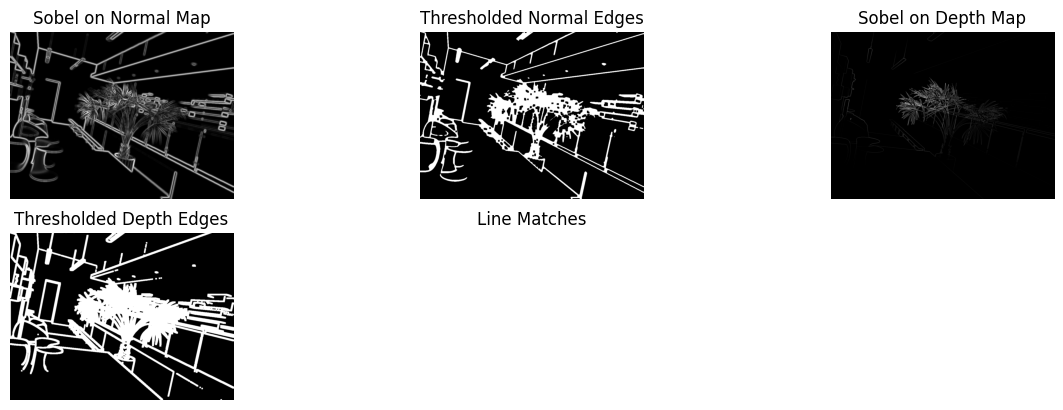

In [1]:
from upload_hypersim import upload_images
import os
import torch
from deeplsd.models.deeplsd_inference import DeepLSD

from ground_truth.main_process import process_image

if __name__ == "__main__":


    frames = [f"{i:04d}" for i in range(1, 100)]
    
    desired_images = [
        #  "ai_001_001",
        #  "ai_001_002",
        #  "ai_001_003",
        #  "ai_001_004",
        #  "ai_001_005",
        #  "ai_001_006",
        #  "ai_001_007",
        # "ai_001_008",
        # "ai_001_009",
        # "ai_001_010",
        # "ai_002_001",
        "ai_002_002",

    ]
    
    print("Generate Images")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
    ckpt = torch.load('../weights/deeplsd_md.tar', map_location=device, weights_only=False)
    net = DeepLSD(conf)
    net.load_state_dict(ckpt['model'])
    net = net.to(device).eval()
    
    for image_id in desired_images:
        for frame_str in frames:
            frame_str = "0085"
            print(f"generate for {image_id}, {frame_str}")
            image_dir = os.path.join("data", image_id)
            cam_view_color = "scene_cam_00_final_preview"

            required_file = os.path.join(image_dir, image_id, "images", cam_view_color, f"frame.{frame_str}.color.jpg")

            if not os.path.isfile(required_file):
                print(f"Skipping: {os.path.join(required_file, )} does not exist.")
                continue
            composite_after, pred_lines, img, normals, world_coordinates, valid_mask, line_info, scores, isstruct, original_lines = process_image(
                image_dir, image_id, frame_str, net, device,
                depth_thresh=50, normal_thresh=1.5 * 1e7,
                dataset="hypersim",
                #moge_model = moge,
                file_path = required_file,
            )
            
    print("Finished processing.")